
# Goodreads k‑NN Book Recommendation System



In [1]:
# importing necessary libraries
import os
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import pickle

import warnings
warnings.filterwarnings("ignore")


## 1. Load & Explore the Dataset

In [2]:
df = pd.read_csv('/content/books.csv', on_bad_lines='skip')


In [3]:
df.head()

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9780439785969,eng,652,2095690,27591,9/16/2006,Scholastic Inc.
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9780439358071,eng,870,2153167,29221,9/1/2004,Scholastic Inc.
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9780439554893,eng,352,6333,244,11/1/2003,Scholastic
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9780439655484,eng,435,2339585,36325,5/1/2004,Scholastic Inc.
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9780439682589,eng,2690,41428,164,9/13/2004,Scholastic


In [4]:
print("Shape:", df.shape)

Shape: (11123, 12)


In [5]:
display(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11123 entries, 0 to 11122
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   bookID              11123 non-null  int64  
 1   title               11123 non-null  object 
 2   authors             11123 non-null  object 
 3   average_rating      11123 non-null  float64
 4   isbn                11123 non-null  object 
 5   isbn13              11123 non-null  int64  
 6   language_code       11123 non-null  object 
 7     num_pages         11123 non-null  int64  
 8   ratings_count       11123 non-null  int64  
 9   text_reviews_count  11123 non-null  int64  
 10  publication_date    11123 non-null  object 
 11  publisher           11123 non-null  object 
dtypes: float64(1), int64(5), object(6)
memory usage: 1.0+ MB


None

In [6]:
df.describe()

,bookID,average_rating,isbn13,num_pages,ratings_count,text_reviews_count
count,11123.000000,11123.000000,1.112300e+04,11123.000000,1.112300e+04,11123.000000
mean,21310.856963,3.934075,9.759880e+12,336.405556,1.794285e+04,542.048099
std,13094.727252,0.350485,4.429758e+11,241.152626,1.124992e+05,2576.619589
min,1.000000,0.000000,8.987060e+09,0.000000,0.000000e+00,0.000000
25%,10277.500000,3.770000,9.780345e+12,192.000000,1.040000e+02,9.000000
50%,20287.000000,3.960000,9.780582e+12,299.000000,7.450000e+02,47.000000
75%,32104.500000,4.140000,9.780872e+12,416.000000,5.000500e+03,238.000000
max,45641.000000,5.000000,9.790008e+12,6576.000000,4.597666e+06,94265.000000


In [7]:
df.columns

Index(['bookID', 'title', 'authors', 'average_rating', 'isbn', 'isbn13',
       'language_code', '  num_pages', 'ratings_count', 'text_reviews_count',
       'publication_date', 'publisher'],
      dtype='object')

In [8]:
# these columns don't contain important information
columns_to_drop = ['bookID', 'isbn', 'isbn13']

df.drop(columns=columns_to_drop, inplace=True)

In [9]:
df.shape

(11123, 9)

In [10]:
df['publication_date']

,publication_date
0,9/16/2006
1,9/1/2004
2,11/1/2003
3,5/1/2004
4,9/13/2004
...,...
11118,12/21/2004
11119,12/1/1988
11120,8/1/1993
11121,2/27/2007


**data type of the publication_date is object. It should be in data and time formate so lets convert it.**

In [11]:
df['publication_date'] = pd.to_datetime(df['publication_date'], errors='coerce')

In [12]:
df.isnull().sum()

,0
title,0
authors,0
average_rating,0
language_code,0
num_pages,0
ratings_count,0
text_reviews_count,0
publication_date,2
publisher,0


In [13]:
df.dropna(subset=['publication_date'], inplace=True)

In [14]:
df.duplicated().sum()

np.int64(0)

# Exploratory data Analysis

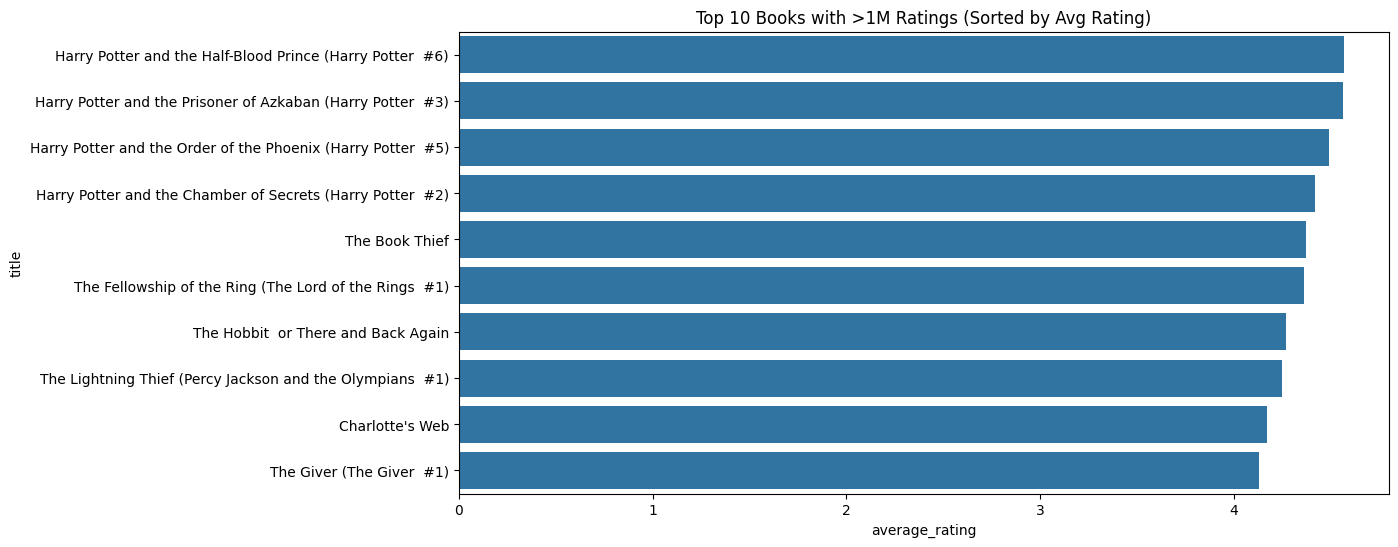

In [15]:
plt.figure(figsize=(12,6))
top_books = df[df['ratings_count'] > 1_000_000].sort_values(by='average_rating', ascending=False).head(10)
sns.barplot(x='average_rating', y='title', data=top_books)
plt.title("Top 10 Books with >1M Ratings (Sorted by Avg Rating)")
plt.show()

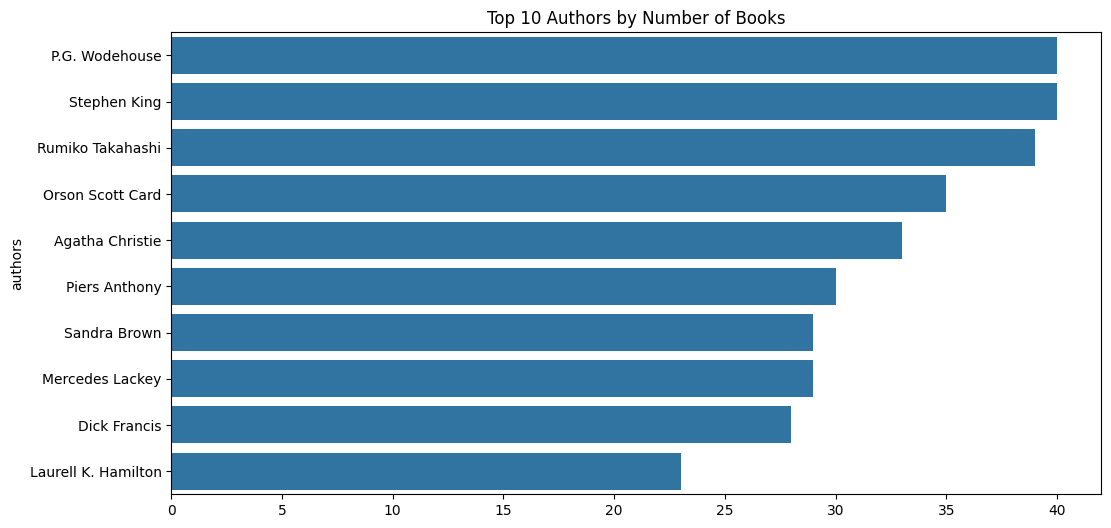

In [16]:
plt.figure(figsize=(12,6))
top_authors = df['authors'].value_counts().head(10)
sns.barplot(x=top_authors.values, y=top_authors.index)
plt.title("Top 10 Authors by Number of Books")
plt.show()

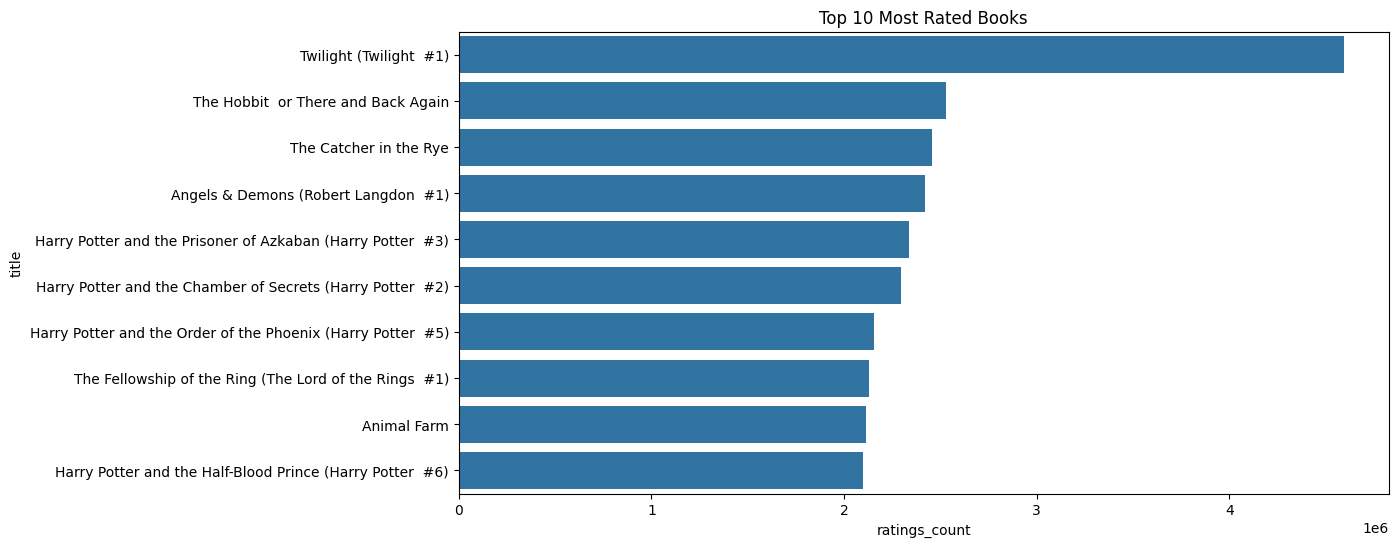

In [17]:
plt.figure(figsize=(12,6))
top_rated_books = df.sort_values(by='ratings_count', ascending=False).head(10)
sns.barplot(x='ratings_count', y='title', data=top_rated_books)
plt.title("Top 10 Most Rated Books")
plt.show()

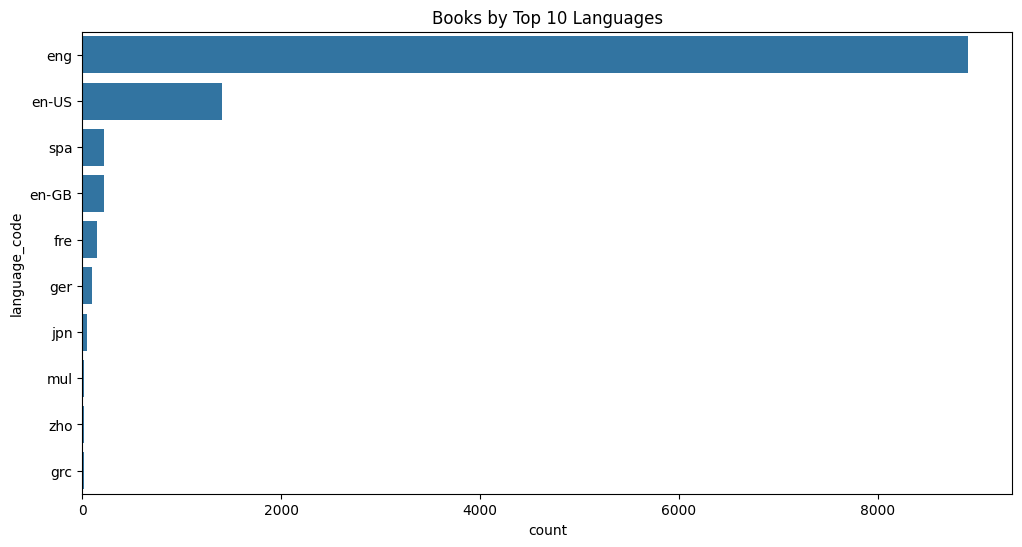

In [18]:
plt.figure(figsize=(12,6))
top_lang = df['language_code'].value_counts().head(10)
sns.countplot(data=df[df['language_code'].isin(top_lang.index)], y='language_code', order=top_lang.index)
plt.title("Books by Top 10 Languages")
plt.show()

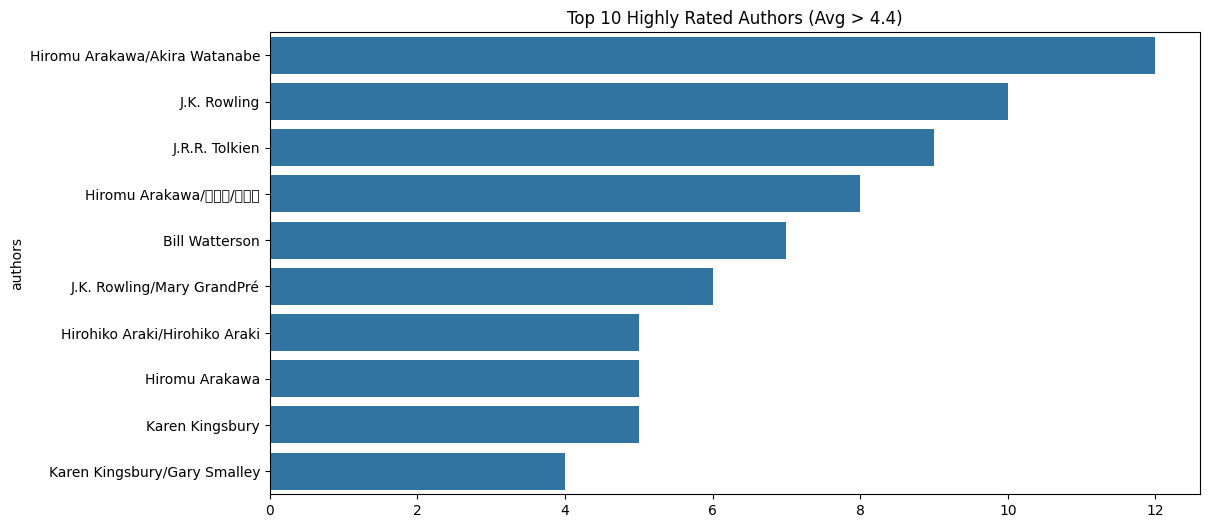

In [19]:
plt.figure(figsize=(12,6))
highly_rated_authors = df[df['average_rating'] > 4.4]['authors'].value_counts().head(10)
sns.barplot(x=highly_rated_authors.values, y=highly_rated_authors.index)
plt.title("Top 10 Highly Rated Authors (Avg > 4.4)")
plt.show()

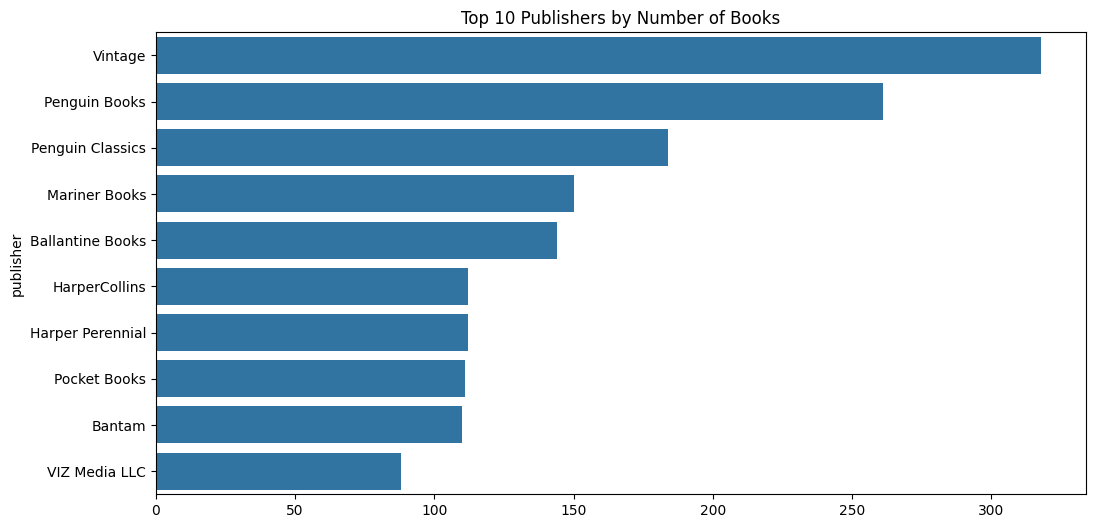

In [20]:
plt.figure(figsize=(12,6))
top_publishers = df['publisher'].value_counts().head(10)
sns.barplot(x=top_publishers.values, y=top_publishers.index)
plt.title("Top 10 Publishers by Number of Books")
plt.show()

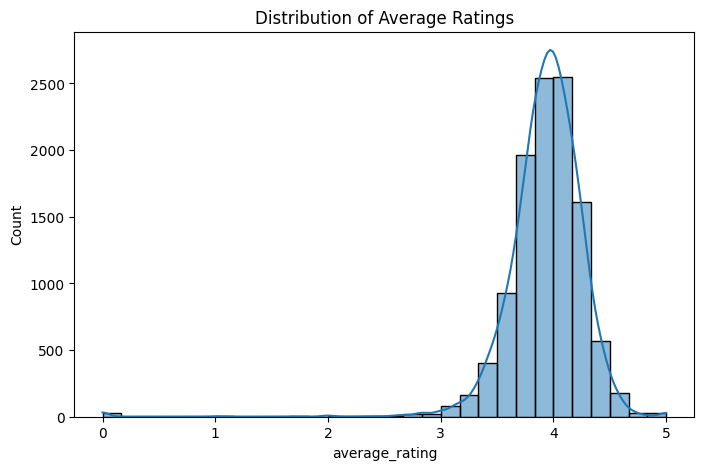

In [21]:
# checking the distribution of the average rating

plt.figure(figsize=(8,5))
sns.histplot(df['average_rating'], bins=30, kde=True)
plt.title("Distribution of Average Ratings")
plt.show()

**its left skeweed means distribution is not normal**

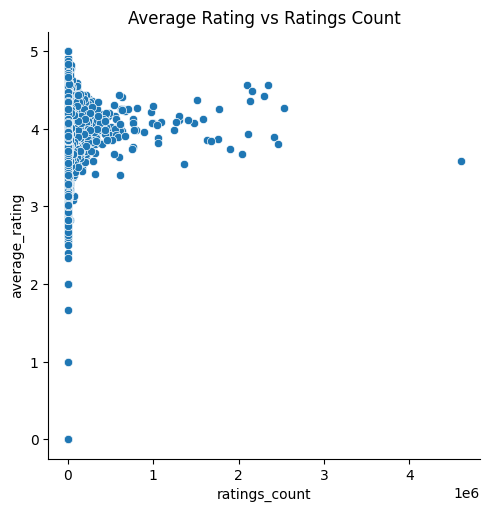

In [22]:
sns.relplot(x='ratings_count', y='average_rating', data=df)
plt.title("Average Rating vs Ratings Count")
plt.show()


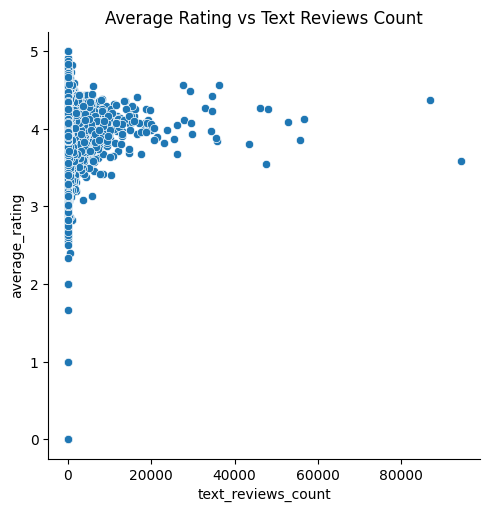

In [23]:
sns.relplot(x='text_reviews_count', y='average_rating', data=df)
plt.title("Average Rating vs Text Reviews Count")
plt.show()

In [24]:
# checking the number of publication per year
df['year'] = df['publication_date'].dt.year

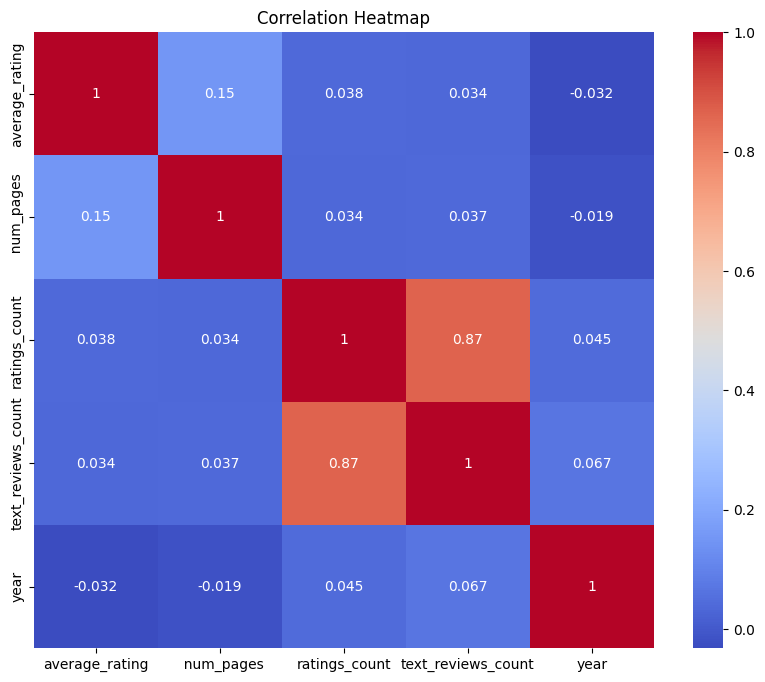

In [25]:
numeric_df = df.select_dtypes(include=np.number)
df_co = numeric_df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(df_co, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Data Preprocessing

In [26]:
df['average_rating']

,average_rating
0,4.57
1,4.49
2,4.42
3,4.56
4,4.78
...,...
11118,4.06
11119,4.08
11120,3.96
11121,3.72


In [27]:
df["average_rating"].nunique()

209

In [28]:
# Rating bins
bins = [0, 1, 2, 3, 4, 5]
labels = ["0-1", "1-2", "2-3", "3-4", "4-5"]
df["rating_between"] = pd.cut(df["average_rating"], bins=bins, labels=labels, include_lowest=True)

In [29]:
df['rating_between'].value_counts().sort_index()

,count
rating_between,
0-1,27
1-2,7
2-3,69
3-4,6284
4-5,4734


In [30]:
lang_counts_full = df["language_code"].value_counts()
lang_counts_full

,count
language_code,
eng,8907
en-US,1408
spa,218
en-GB,214
fre,143
ger,99
jpn,46
mul,19
zho,14


In [31]:
# Top-10 languages only; others go to 'other'

top10_langs = set(lang_counts_full.head(10).index)
df["lang_top10"] = df["language_code"].apply(lambda x: x if x in top10_langs else "other")

In [32]:
# Dummies
rating_dummies = pd.get_dummies(df["rating_between"], prefix="bin", drop_first=True)
lang_dummies = pd.get_dummies(df["lang_top10"], prefix="lang", drop_first=True)

In [33]:
# Combine features
features = pd.concat([df[['average_rating','ratings_count']], lang_dummies, rating_dummies], axis=1)

In [34]:
features

,average_rating,ratings_count,lang_en-US,lang_eng,lang_fre,lang_ger,lang_grc,lang_jpn,lang_mul,lang_other,lang_spa,lang_zho,bin_1-2,bin_2-3,bin_3-4,bin_4-5
0,4.57,2095690,False,True,False,False,False,False,False,False,False,False,False,False,False,True
1,4.49,2153167,False,True,False,False,False,False,False,False,False,False,False,False,False,True
2,4.42,6333,False,True,False,False,False,False,False,False,False,False,False,False,False,True
3,4.56,2339585,False,True,False,False,False,False,False,False,False,False,False,False,False,True
4,4.78,41428,False,True,False,False,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11118,4.06,156,False,True,False,False,False,False,False,False,False,False,False,False,False,True
11119,4.08,783,False,True,False,False,False,False,False,False,False,False,False,False,False,True
11120,3.96,820,False,True,False,False,False,False,False,False,False,False,False,False,True,False
11121,3.72,769,False,True,False,False,False,False,False,False,False,False,False,False,True,False


In [35]:
# Scale features
scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(features)

In [36]:
print("Feature shape:", features_scaled.shape)
feature_columns = features.columns.tolist()

Feature shape: (11121, 16)


In [44]:
# Save the scaler
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

# Model Building

In [37]:
model_knn = NearestNeighbors(n_neighbors=6, algorithm='ball_tree')
model_knn.fit(features_scaled)

NearestNeighbors(algorithm='ball_tree', n_neighbors=6)

In [38]:
# Index for fast lookup
title_to_index = {t.lower(): i for i, t in enumerate(df["title"])}

In [39]:
from typing import List, Tuple
import difflib

def _resolve_title(query: str) -> Tuple[int, str]:
    """
    Resolve a user-provided title to the closest match in the dataset (case-insensitive).
    Returns (index, matched_title). Raises ValueError if nothing plausible is found.
    """
    titles_lower = [t.lower() for t in df["title"].astype(str).tolist()]
    matches = difflib.get_close_matches(query.lower(), titles_lower, n=1, cutoff=0.6)
    if not matches:
        raise ValueError(f"Title '{query}' not found (no close match).")
    matched_lower = matches[0]
    idx = titles_lower.index(matched_lower)
    matched_title = df.iloc[idx]["title"]
    return idx, matched_title

In [40]:
def BookRecommender(title: str, n_recs: int = 5) -> pd.DataFrame:
    """
    Given a title, return n_recs recommended book titles using k-NN over feature space.
    """
    idx, matched = _resolve_title(title)
    distances, indices = model_knn.kneighbors([features_scaled[idx]], n_neighbors=n_recs + 1)
    rec_indices = [i for i in indices.flatten() if i != idx][:n_recs]

    out = df.loc[rec_indices, ["title", "authors", "average_rating", "ratings_count", "publisher"]].copy()
    out["distance"] = distances.flatten()[1:n_recs + 1]
    out = out.sort_values("distance")
    return out.reset_index(drop=True)

In [41]:
try:
    display(BookRecommender("The Hunger Games", n_recs=5).head())
except Exception as e:
    print("Test with 'The Hunger Games':", e)

,title,authors,average_rating,ratings_count,publisher,distance
0,Bite Club (Bite Club #1),Howard Chaykin/David Tischman/David Hahn,3.07,148,Vertigo (DC Comics),0.000007
1,The Devil in the Junior League,Linda Francis Lee,3.62,3852,St. Martin's Press,0.000012
2,Deep Waters (Cetin Ikmen #4),Barbara Nadel,3.99,301,Headline,0.000066
3,Heart of Darkness,Joseph Conrad,3.42,92,Wildside Press,0.000068
4,The Science of Stephen King: From 'Carrie' to ...,Lois H. Gresh/Robert E. Weinberg,3.42,62,Wiley,0.000075


In [42]:
try:
    display(BookRecommender("Twilight", n_recs=5).head())
except Exception as e:
    print("Test with 'Twilight':", e)

,title,authors,average_rating,ratings_count,publisher,distance
0,Plain Truth,Jodi Picoult,3.98,143658,Atria Books,0.001209
1,The Wind in the Willows,Kenneth Grahame/Gillian Avery,3.99,147748,Penguin Books,0.002899
2,The Wedding (The Notebook #2),Nicholas Sparks,3.99,126629,Vision,0.003198
3,Heidi (Heidi #1-2),Johanna Spyri/Beverly Cleary/Angelo Rinaldi,3.99,153317,Kingfisher,0.003867
4,Sorrow's Anthem (Lincoln Perry #2),Michael Koryta,3.89,62,St. Martin's Paperbacks,0.004026


In [43]:
# saving the model pkl file
with open('knn_book_recommendor.pkl', 'wb') as file:
    pickle.dump(model_knn, file)